_**2. WAP to implement a multi-layer perceptron (MLP) network with one hidden layer using numpy in Python. Demonstrate that it can learn the XOR Boolean function.**_

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score

class MLP:
    def __init__(self, input_size, hidden_size, output_size, learning_rate=0.1, epochs=10000):
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.learning_rate = learning_rate
        self.epochs = epochs
        
        # Initialize weights and biases
        np.random.seed(42)
        self.weights_input_hidden = np.random.randn(input_size, hidden_size)
        self.weights_hidden_output = np.random.randn(hidden_size, output_size)
        self.bias_hidden = np.zeros((1, hidden_size))
        self.bias_output = np.zeros((1, output_size))
        self.loss_history = []
    
    def step_function(self, x):
        return np.where(x >= 0, 1, 0)
    
    def train(self, X, y):
        for epoch in range(self.epochs):
            # Forward pass
            hidden_layer_input = np.dot(X, self.weights_input_hidden) + self.bias_hidden
            hidden_layer_output = self.step_function(hidden_layer_input)
            output_layer_input = np.dot(hidden_layer_output, self.weights_hidden_output) + self.bias_output
            output_layer_output = self.step_function(output_layer_input)
            
            # Compute error
            error = y - output_layer_output
            loss = np.mean(np.abs(error))
            self.loss_history.append(loss)
            
            # Weight update using Perceptron rule
            self.weights_hidden_output += np.dot(hidden_layer_output.T, error) * self.learning_rate
            self.weights_input_hidden += np.dot(X.T, np.dot(error, self.weights_hidden_output.T)) * self.learning_rate
            self.bias_output += np.sum(error, axis=0, keepdims=True) * self.learning_rate
            self.bias_hidden += np.sum(np.dot(error, self.weights_hidden_output.T), axis=0, keepdims=True) * self.learning_rate
            
            # Print loss every 1000 epochs
            if epoch % 1000 == 0:
                print(f"Epoch {epoch}: Loss = {loss}")
    
    def predict(self, X):
        hidden_layer_activation = self.step_function(np.dot(X, self.weights_input_hidden) + self.bias_hidden)
        final_output = self.step_function(np.dot(hidden_layer_activation, self.weights_hidden_output) + self.bias_output)
        return final_output
    
    def evaluate(self, X, y):
        predictions = self.predict(X)
        accuracy = accuracy_score(y, predictions)
        conf_matrix = confusion_matrix(y, predictions)
        print(f"Accuracy: {accuracy * 100:.2f}%")
        print("Confusion Matrix:")
        print(conf_matrix)
        
    def plot_loss_curve(self):
        plt.figure()
        plt.plot(self.loss_history, label='Loss')
        plt.xlabel('Epochs')
        plt.ylabel('Loss')
        plt.title('Loss Curve')
        plt.legend()
        plt.show()
        
    def plot_decision_boundary(self, X, y):
        x_min, x_max = -0.5, 1.5
        y_min, y_max = -0.5, 1.5
        xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
        Z = np.array([self.predict(np.array([[x, y]])) for x, y in zip(xx.ravel(), yy.ravel())])
        Z = Z.reshape(xx.shape)
        
        plt.contourf(xx, yy, Z, alpha=0.3)
        plt.scatter(X[:, 0], X[:, 1], c=y.ravel(), edgecolors='k', marker='o')
        plt.xlabel("Input 1")
        plt.ylabel("Input 2")
        plt.title("Decision Boundary of XOR MLP")
        plt.show()


Epoch 0: Loss = 0.5
Epoch 1000: Loss = 0.5
Epoch 2000: Loss = 0.5
Epoch 3000: Loss = 0.5
Epoch 4000: Loss = 0.5
Epoch 5000: Loss = 0.5
Epoch 6000: Loss = 0.5
Epoch 7000: Loss = 0.5
Epoch 8000: Loss = 0.5
Epoch 9000: Loss = 0.5
Accuracy: 50.00%
Confusion Matrix:
[[0 2]
 [0 2]]


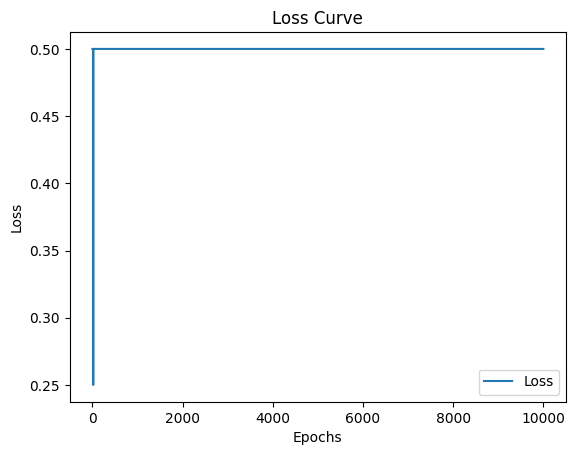

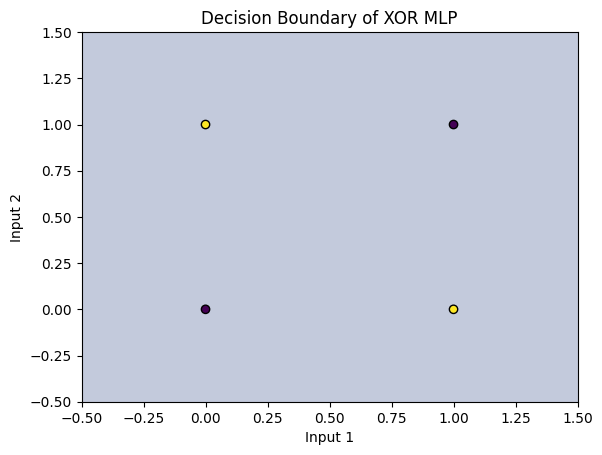

In [2]:

# Initialize dataset (XOR truth table)
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([[0], [1], [1], [0]])

# Train MLP
mlp = MLP(input_size=2, hidden_size=1, output_size=1, learning_rate=0.1, epochs=10000)
mlp.train(X, y)

# Evaluate performance
mlp.evaluate(X, y)
mlp.plot_loss_curve()
mlp.plot_decision_boundary(X, y)

Epoch 0: Loss = 0.25
Epoch 1000: Loss = 0.0
Epoch 2000: Loss = 0.0
Epoch 3000: Loss = 0.0
Epoch 4000: Loss = 0.0
Epoch 5000: Loss = 0.0
Epoch 6000: Loss = 0.0
Epoch 7000: Loss = 0.0
Epoch 8000: Loss = 0.0
Epoch 9000: Loss = 0.0
Accuracy: 100.00%
Confusion Matrix:
[[2 0]
 [0 2]]


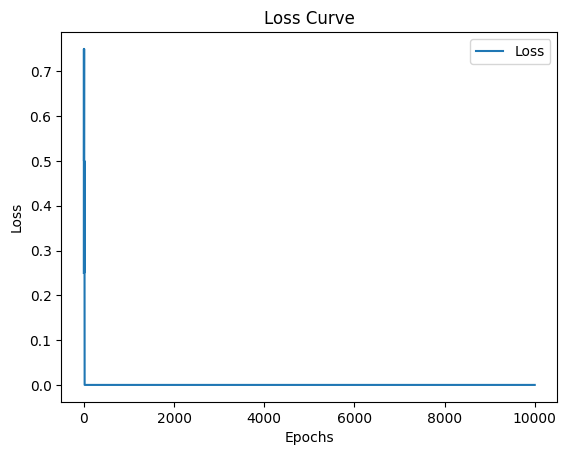

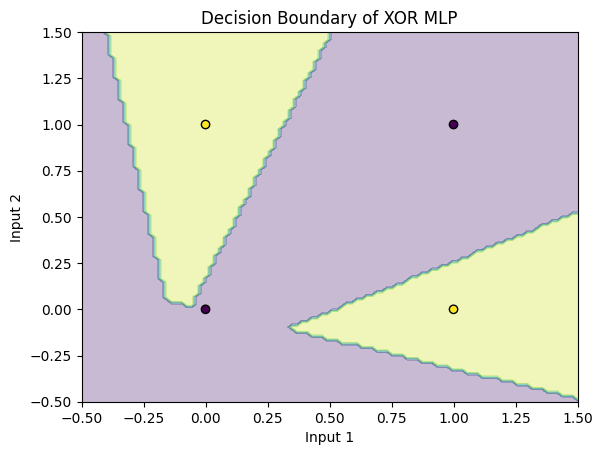

In [3]:

# Initialize dataset (XOR truth table)
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([[0], [1], [1], [0]])

# Train MLP
mlp = MLP(input_size=2, hidden_size=8, output_size=1, learning_rate=0.1, epochs=10000)
mlp.train(X, y)

# Evaluate performance
mlp.evaluate(X, y)
mlp.plot_loss_curve()
mlp.plot_decision_boundary(X, y)

In [4]:
# Initialize dataset (XOR truth table)
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([[0], [1], [1], [0]])


In [5]:
def test_mlp(hidden_size=2, learning_rate=0.1, epochs=10000):
    # Train MLP
    mlp = MLP(input_size=2, hidden_size=hidden_size, output_size=1, learning_rate=learning_rate, epochs=epochs)
    mlp.train(X, y)

    # Evaluate performance
    mlp.evaluate(X, y)
    mlp.plot_loss_curve()
    mlp.plot_decision_boundary(X, y)

Epoch 0: Loss = 0.5
Epoch 1000: Loss = 0.5
Epoch 2000: Loss = 0.5
Epoch 3000: Loss = 0.5
Epoch 4000: Loss = 0.5
Epoch 5000: Loss = 0.5
Epoch 6000: Loss = 0.5
Epoch 7000: Loss = 0.5
Epoch 8000: Loss = 0.5
Epoch 9000: Loss = 0.5
Accuracy: 50.00%
Confusion Matrix:
[[0 2]
 [0 2]]


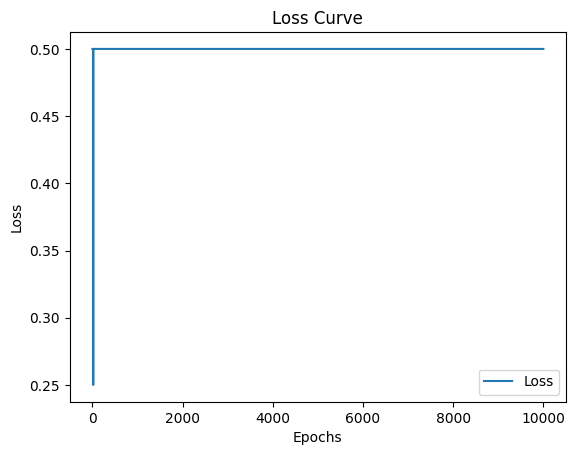

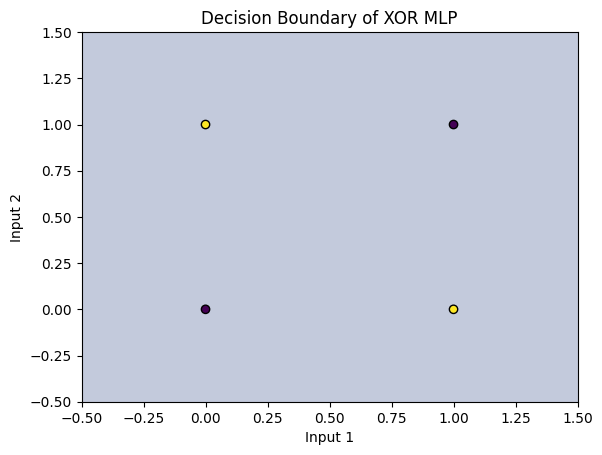

done :- 0
Epoch 0: Loss = 0.5
Epoch 1000: Loss = 0.5
Epoch 2000: Loss = 0.5
Epoch 3000: Loss = 0.5
Epoch 4000: Loss = 0.5
Epoch 5000: Loss = 0.5
Epoch 6000: Loss = 0.5
Epoch 7000: Loss = 0.5
Epoch 8000: Loss = 0.5
Epoch 9000: Loss = 0.5
Accuracy: 50.00%
Confusion Matrix:
[[2 0]
 [2 0]]


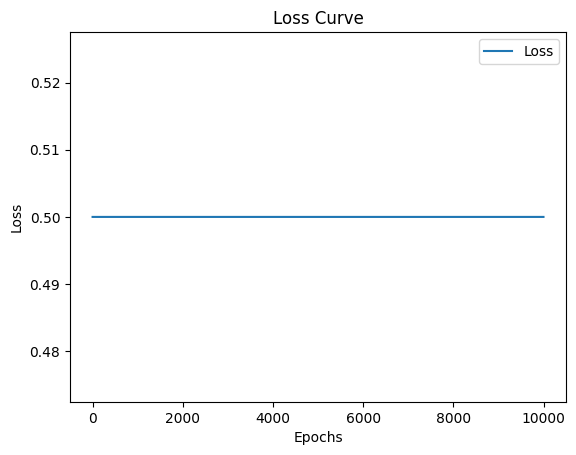

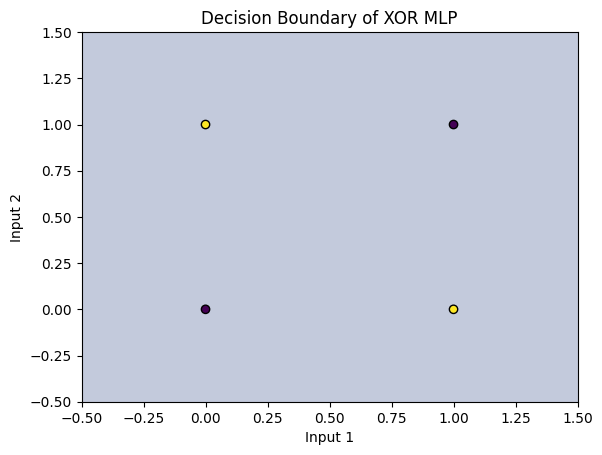

done :- 1
Epoch 0: Loss = 0.5
Epoch 1000: Loss = 0.5
Epoch 2000: Loss = 0.5
Epoch 3000: Loss = 0.5
Epoch 4000: Loss = 0.5
Epoch 5000: Loss = 0.5
Epoch 6000: Loss = 0.5
Epoch 7000: Loss = 0.5
Epoch 8000: Loss = 0.5
Epoch 9000: Loss = 0.5
Accuracy: 50.00%
Confusion Matrix:
[[0 2]
 [0 2]]


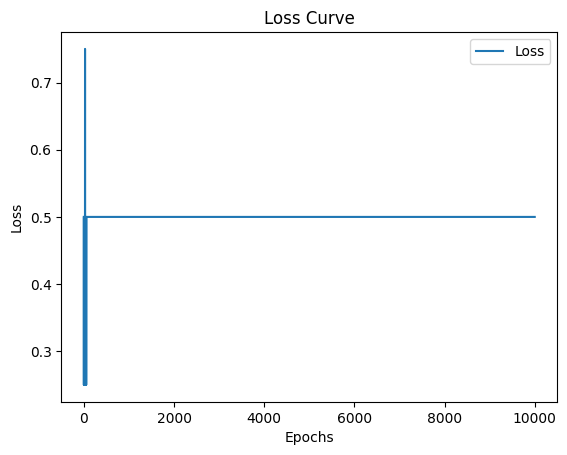

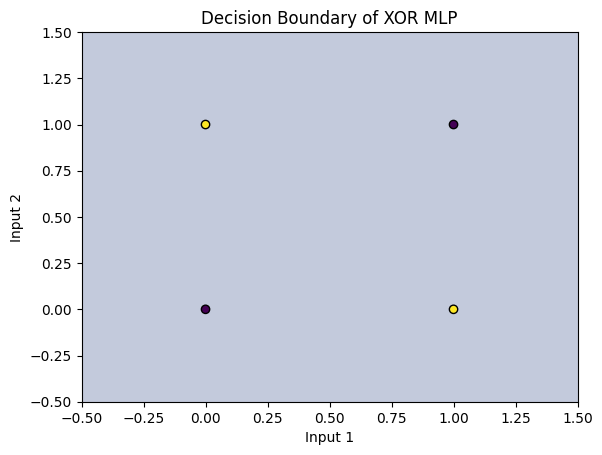

done :- 2
Epoch 0: Loss = 0.5
Epoch 1000: Loss = 0.5
Epoch 2000: Loss = 0.5
Epoch 3000: Loss = 0.5
Epoch 4000: Loss = 0.5
Epoch 5000: Loss = 0.5
Epoch 6000: Loss = 0.5
Epoch 7000: Loss = 0.5
Epoch 8000: Loss = 0.5
Epoch 9000: Loss = 0.5
Accuracy: 50.00%
Confusion Matrix:
[[0 2]
 [0 2]]


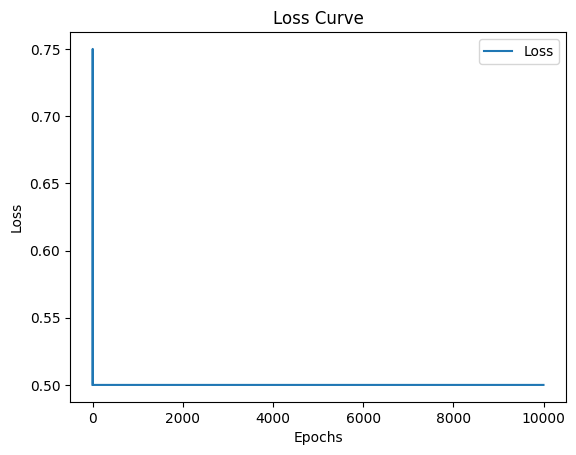

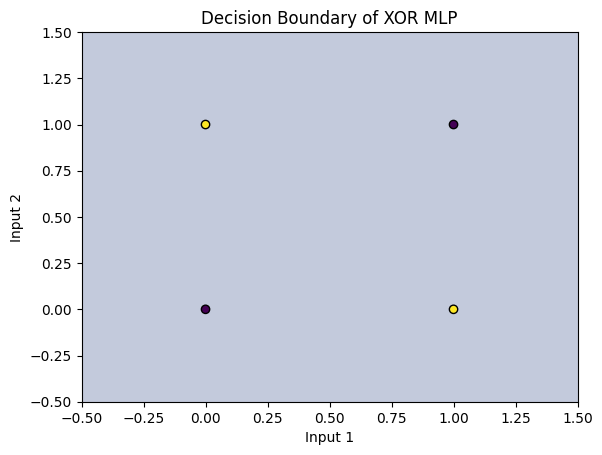

done :- 3
Epoch 0: Loss = 0.5
Epoch 1000: Loss = 0.0
Epoch 2000: Loss = 0.0
Epoch 3000: Loss = 0.0
Epoch 4000: Loss = 0.0
Epoch 5000: Loss = 0.0
Epoch 6000: Loss = 0.0
Epoch 7000: Loss = 0.0
Epoch 8000: Loss = 0.0
Epoch 9000: Loss = 0.0
Accuracy: 100.00%
Confusion Matrix:
[[2 0]
 [0 2]]


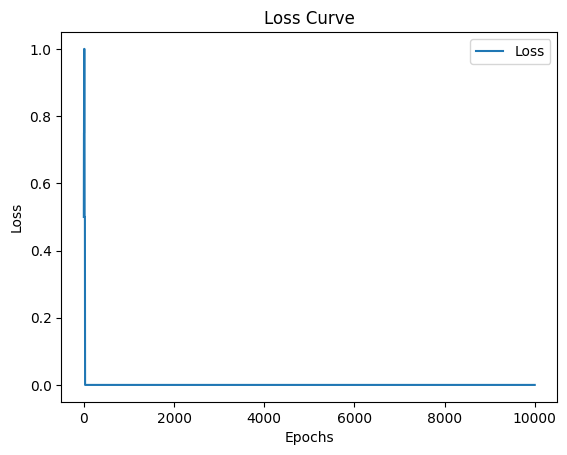

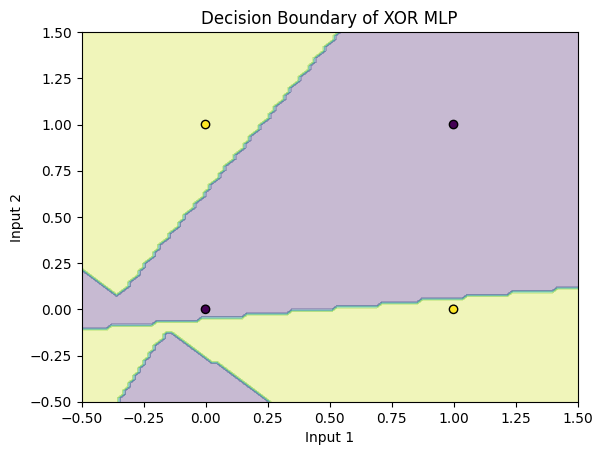

done :- 4
Epoch 0: Loss = 0.5
Epoch 1000: Loss = 0.5
Epoch 2000: Loss = 0.5
Epoch 3000: Loss = 0.5
Epoch 4000: Loss = 0.5
Epoch 5000: Loss = 0.5
Epoch 6000: Loss = 0.5
Epoch 7000: Loss = 0.5
Epoch 8000: Loss = 0.5
Epoch 9000: Loss = 0.5
Accuracy: 50.00%
Confusion Matrix:
[[0 2]
 [0 2]]


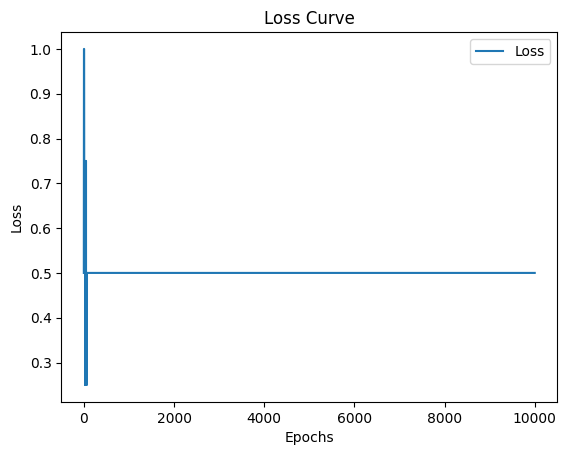

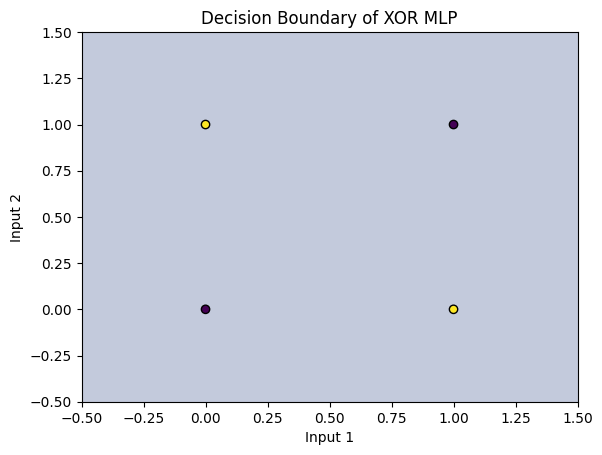

done :- 5
Epoch 0: Loss = 0.5
Epoch 1000: Loss = 0.5
Epoch 2000: Loss = 0.5
Epoch 3000: Loss = 0.5
Epoch 4000: Loss = 0.5
Epoch 5000: Loss = 0.5
Epoch 6000: Loss = 0.5
Epoch 7000: Loss = 0.5
Epoch 8000: Loss = 0.5
Epoch 9000: Loss = 0.5
Accuracy: 50.00%
Confusion Matrix:
[[0 2]
 [0 2]]


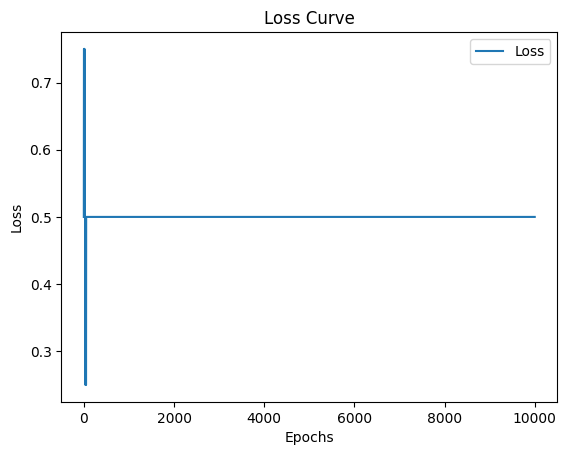

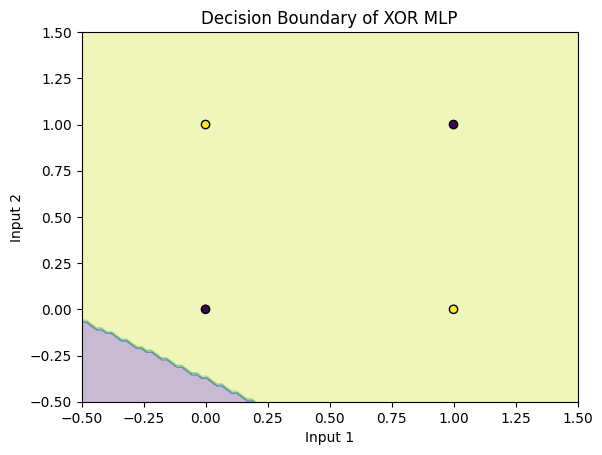

done :- 6
Epoch 0: Loss = 0.25
Epoch 1000: Loss = 0.0
Epoch 2000: Loss = 0.0
Epoch 3000: Loss = 0.0
Epoch 4000: Loss = 0.0
Epoch 5000: Loss = 0.0
Epoch 6000: Loss = 0.0
Epoch 7000: Loss = 0.0
Epoch 8000: Loss = 0.0
Epoch 9000: Loss = 0.0
Accuracy: 100.00%
Confusion Matrix:
[[2 0]
 [0 2]]


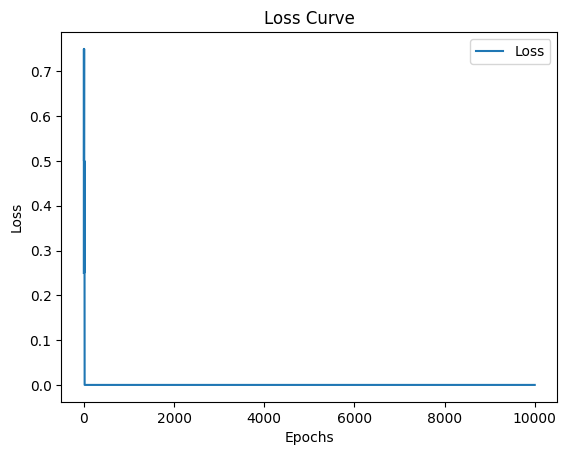

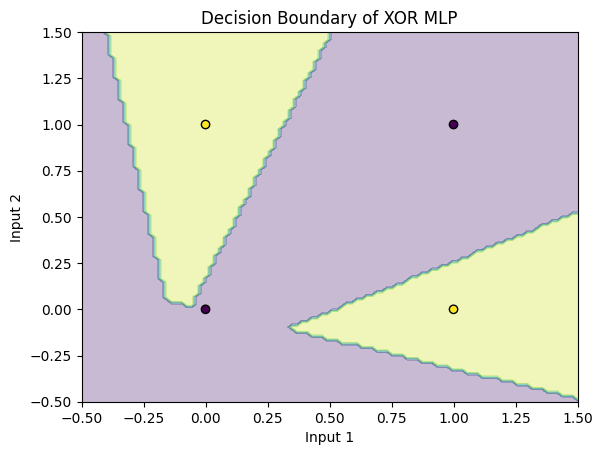

done :- 7
Epoch 0: Loss = 0.5
Epoch 1000: Loss = 0.5
Epoch 2000: Loss = 0.5
Epoch 3000: Loss = 0.5
Epoch 4000: Loss = 0.5
Epoch 5000: Loss = 0.5
Epoch 6000: Loss = 0.5
Epoch 7000: Loss = 0.5
Epoch 8000: Loss = 0.5
Epoch 9000: Loss = 0.5
Accuracy: 50.00%
Confusion Matrix:
[[0 2]
 [0 2]]


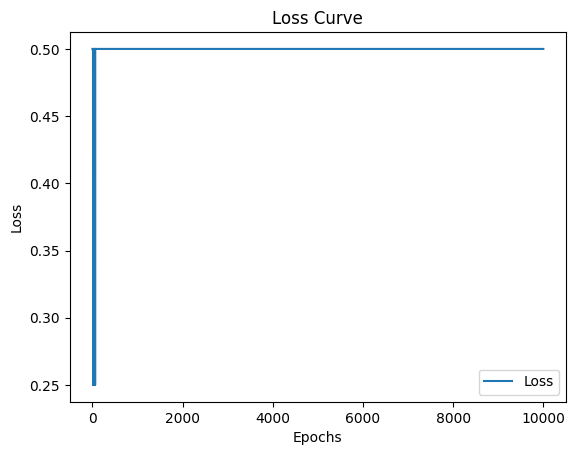

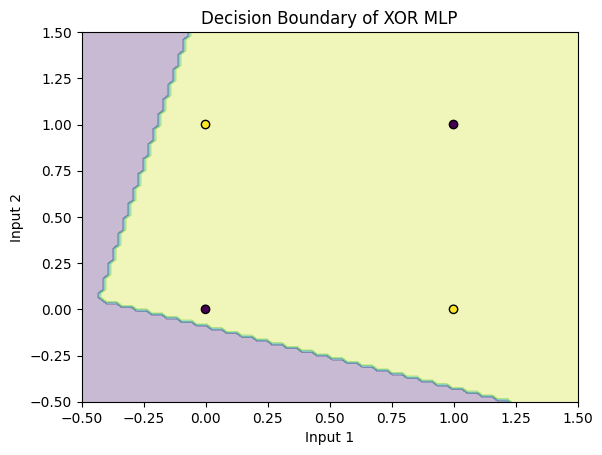

done :- 8
Epoch 0: Loss = 0.5
Epoch 1000: Loss = 0.0
Epoch 2000: Loss = 0.0
Epoch 3000: Loss = 0.0
Epoch 4000: Loss = 0.0
Epoch 5000: Loss = 0.0
Epoch 6000: Loss = 0.0
Epoch 7000: Loss = 0.0
Epoch 8000: Loss = 0.0
Epoch 9000: Loss = 0.0
Accuracy: 100.00%
Confusion Matrix:
[[2 0]
 [0 2]]


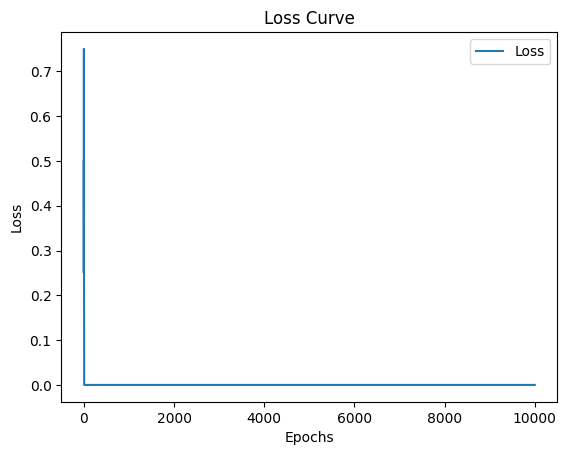

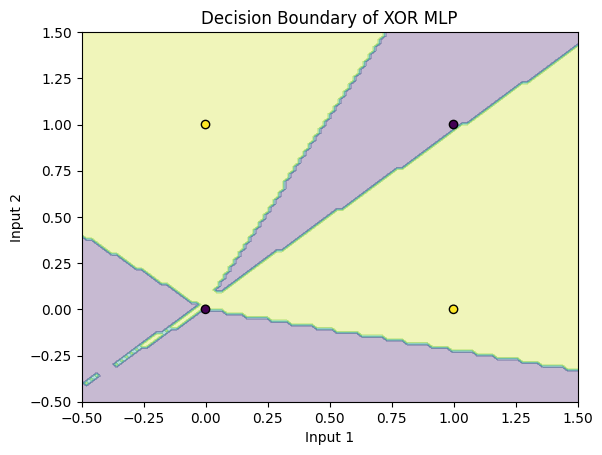

done :- 9


In [6]:
for i in range(10):
    test_mlp(hidden_size=i+1, learning_rate=0.1, epochs=10000)
    print(f"done :- {i}")

Epoch 0: Loss = 0.5
Epoch 1000: Loss = 0.5
Epoch 2000: Loss = 0.5
Epoch 3000: Loss = 0.5
Epoch 4000: Loss = 0.5
Epoch 5000: Loss = 0.5
Epoch 6000: Loss = 0.5
Epoch 7000: Loss = 0.5
Epoch 8000: Loss = 0.5
Epoch 9000: Loss = 0.5
Accuracy: 50.00%
Confusion Matrix:
[[0 2]
 [0 2]]


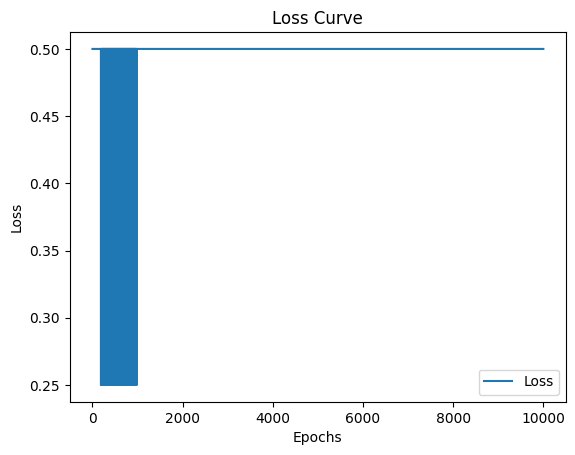

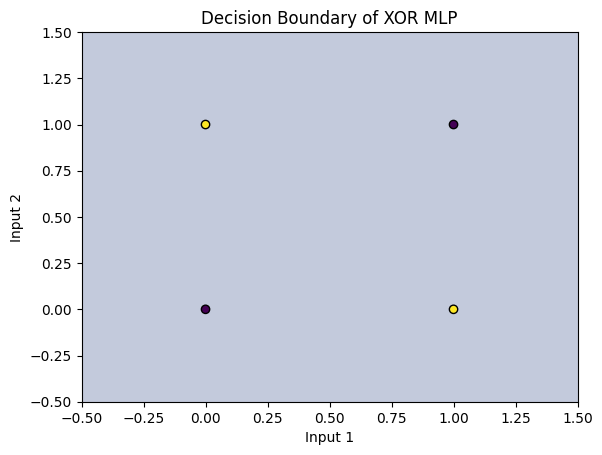

done :- 0
Epoch 0: Loss = 0.5
Epoch 1000: Loss = 0.5
Epoch 2000: Loss = 0.5
Epoch 3000: Loss = 0.5
Epoch 4000: Loss = 0.5
Epoch 5000: Loss = 0.5
Epoch 6000: Loss = 0.5
Epoch 7000: Loss = 0.5
Epoch 8000: Loss = 0.5
Epoch 9000: Loss = 0.5
Accuracy: 50.00%
Confusion Matrix:
[[0 2]
 [0 2]]


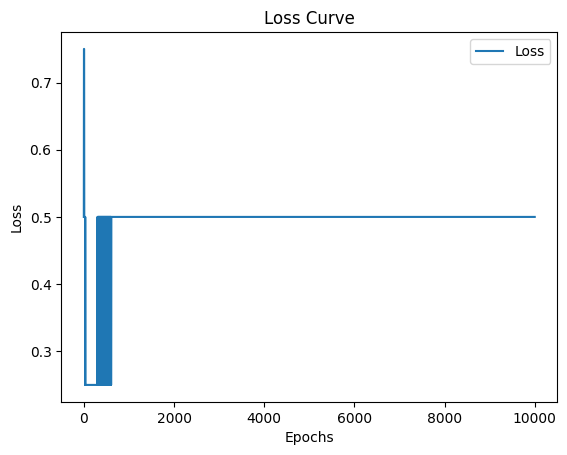

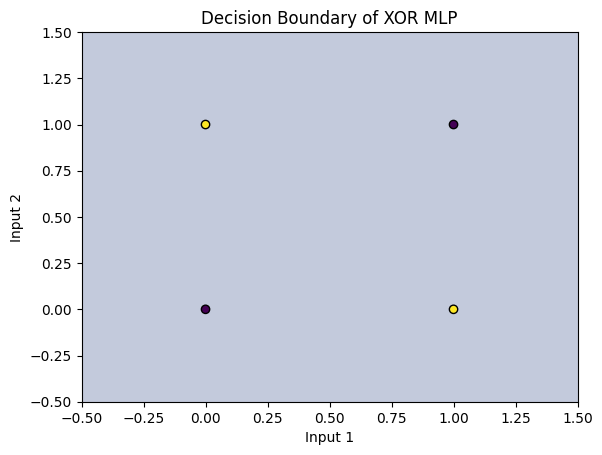

done :- 1
Epoch 0: Loss = 0.5
Epoch 1000: Loss = 0.25
Epoch 2000: Loss = 0.5
Epoch 3000: Loss = 0.25
Epoch 4000: Loss = 0.0
Epoch 5000: Loss = 0.0
Epoch 6000: Loss = 0.0
Epoch 7000: Loss = 0.0
Epoch 8000: Loss = 0.0
Epoch 9000: Loss = 0.0
Accuracy: 100.00%
Confusion Matrix:
[[2 0]
 [0 2]]


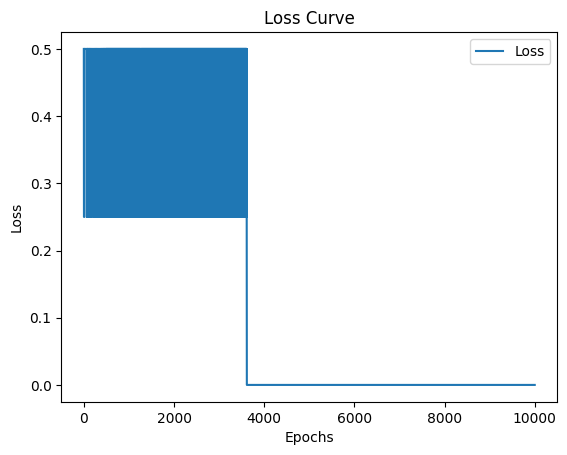

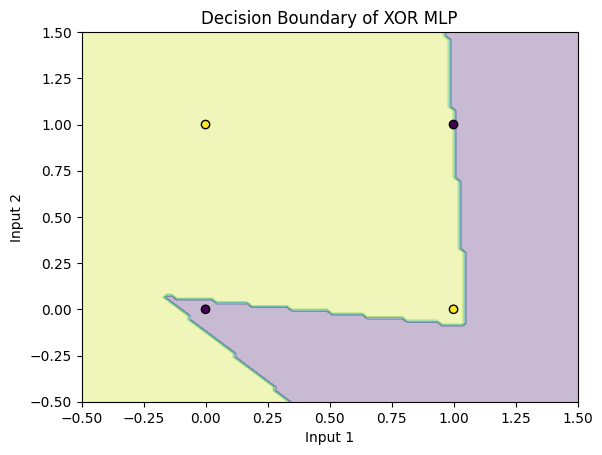

done :- 2
Epoch 0: Loss = 0.5
Epoch 1000: Loss = 0.0
Epoch 2000: Loss = 0.0
Epoch 3000: Loss = 0.0
Epoch 4000: Loss = 0.0
Epoch 5000: Loss = 0.0
Epoch 6000: Loss = 0.0
Epoch 7000: Loss = 0.0
Epoch 8000: Loss = 0.0
Epoch 9000: Loss = 0.0
Accuracy: 100.00%
Confusion Matrix:
[[2 0]
 [0 2]]


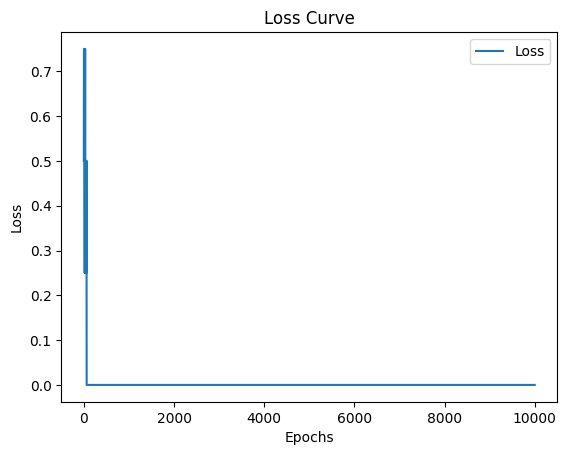

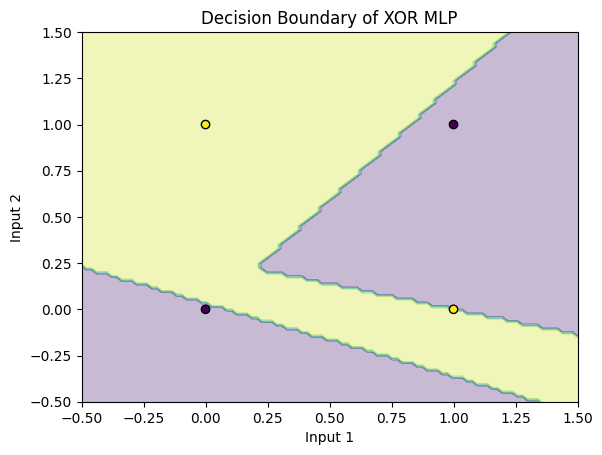

done :- 3
Epoch 0: Loss = 0.5
Epoch 1000: Loss = 0.0
Epoch 2000: Loss = 0.0
Epoch 3000: Loss = 0.0
Epoch 4000: Loss = 0.0
Epoch 5000: Loss = 0.0
Epoch 6000: Loss = 0.0
Epoch 7000: Loss = 0.0
Epoch 8000: Loss = 0.0
Epoch 9000: Loss = 0.0
Accuracy: 100.00%
Confusion Matrix:
[[2 0]
 [0 2]]


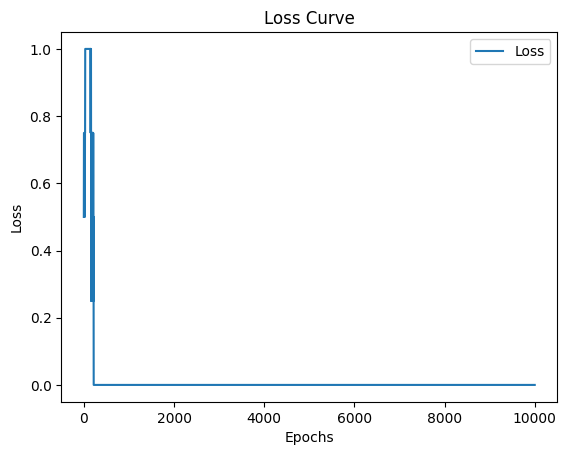

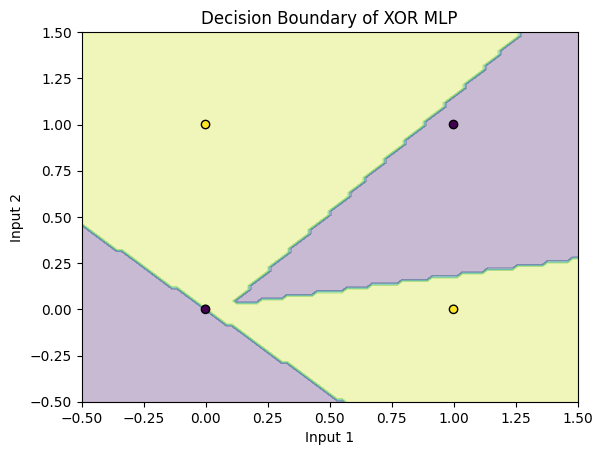

done :- 4
Epoch 0: Loss = 0.5
Epoch 1000: Loss = 0.0
Epoch 2000: Loss = 0.0
Epoch 3000: Loss = 0.0
Epoch 4000: Loss = 0.0
Epoch 5000: Loss = 0.0
Epoch 6000: Loss = 0.0
Epoch 7000: Loss = 0.0
Epoch 8000: Loss = 0.0
Epoch 9000: Loss = 0.0
Accuracy: 100.00%
Confusion Matrix:
[[2 0]
 [0 2]]


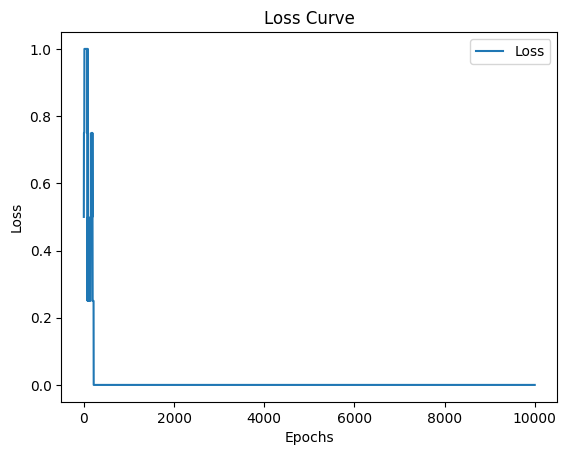

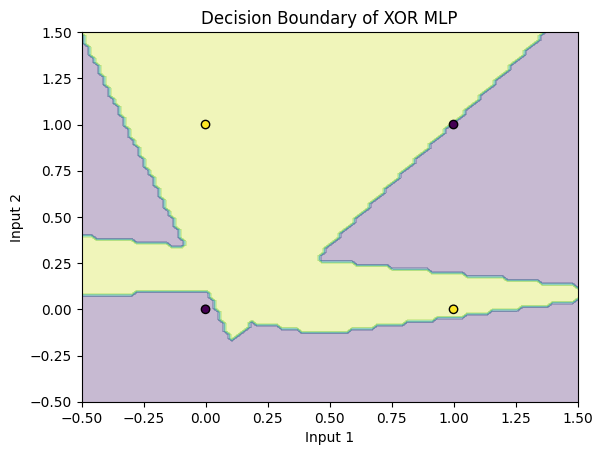

done :- 5
Epoch 0: Loss = 0.5
Epoch 1000: Loss = 0.0
Epoch 2000: Loss = 0.0
Epoch 3000: Loss = 0.0
Epoch 4000: Loss = 0.0
Epoch 5000: Loss = 0.0
Epoch 6000: Loss = 0.0
Epoch 7000: Loss = 0.0
Epoch 8000: Loss = 0.0
Epoch 9000: Loss = 0.0
Accuracy: 100.00%
Confusion Matrix:
[[2 0]
 [0 2]]


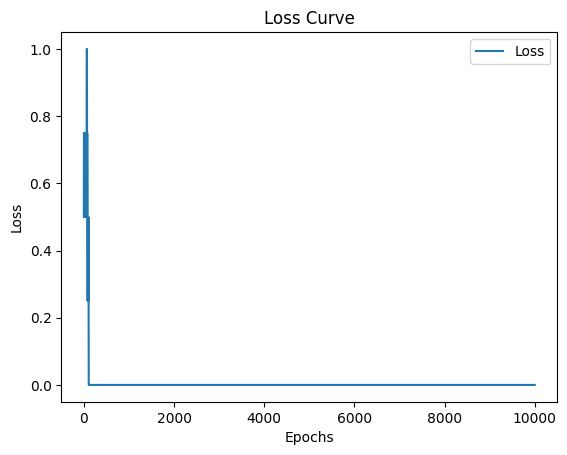

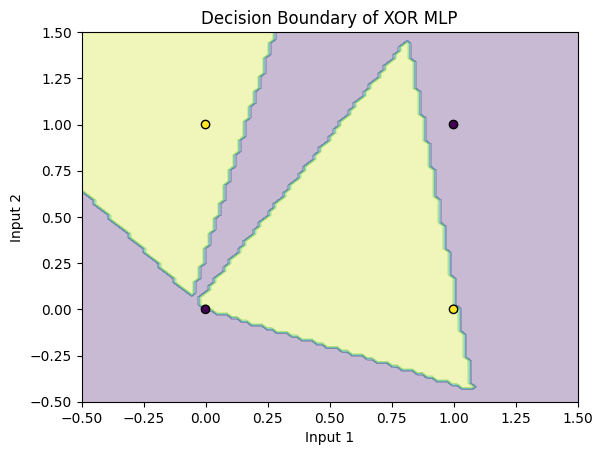

done :- 6
Epoch 0: Loss = 0.25
Epoch 1000: Loss = 0.0
Epoch 2000: Loss = 0.0
Epoch 3000: Loss = 0.0
Epoch 4000: Loss = 0.0
Epoch 5000: Loss = 0.0
Epoch 6000: Loss = 0.0
Epoch 7000: Loss = 0.0
Epoch 8000: Loss = 0.0
Epoch 9000: Loss = 0.0
Accuracy: 100.00%
Confusion Matrix:
[[2 0]
 [0 2]]


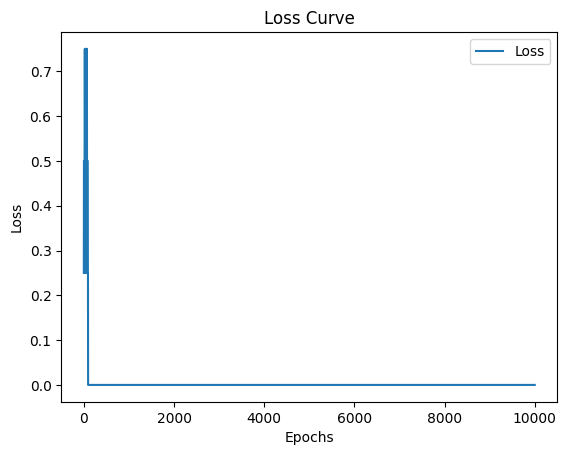

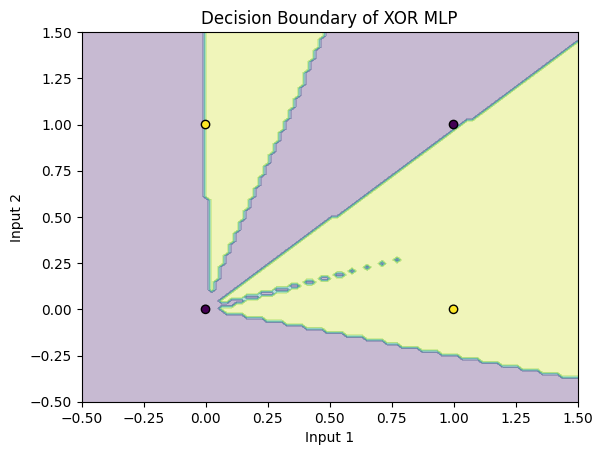

done :- 7
Epoch 0: Loss = 0.5
Epoch 1000: Loss = 0.0
Epoch 2000: Loss = 0.0
Epoch 3000: Loss = 0.0
Epoch 4000: Loss = 0.0
Epoch 5000: Loss = 0.0
Epoch 6000: Loss = 0.0
Epoch 7000: Loss = 0.0
Epoch 8000: Loss = 0.0
Epoch 9000: Loss = 0.0
Accuracy: 100.00%
Confusion Matrix:
[[2 0]
 [0 2]]


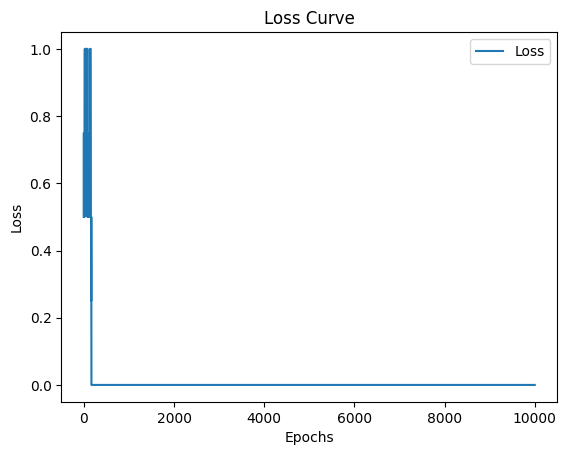

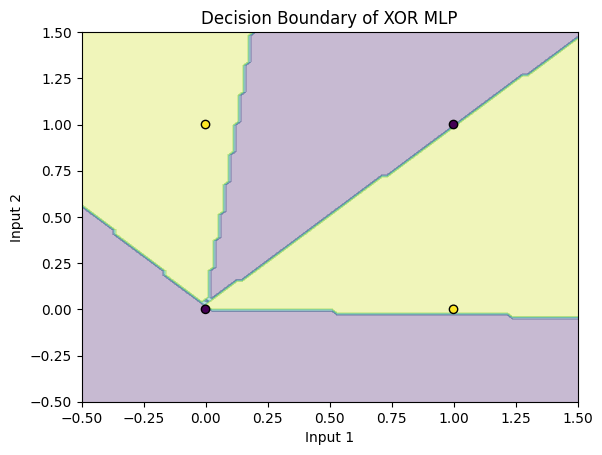

done :- 8
Epoch 0: Loss = 0.5
Epoch 1000: Loss = 0.0
Epoch 2000: Loss = 0.0
Epoch 3000: Loss = 0.0
Epoch 4000: Loss = 0.0
Epoch 5000: Loss = 0.0
Epoch 6000: Loss = 0.0
Epoch 7000: Loss = 0.0
Epoch 8000: Loss = 0.0
Epoch 9000: Loss = 0.0
Accuracy: 100.00%
Confusion Matrix:
[[2 0]
 [0 2]]


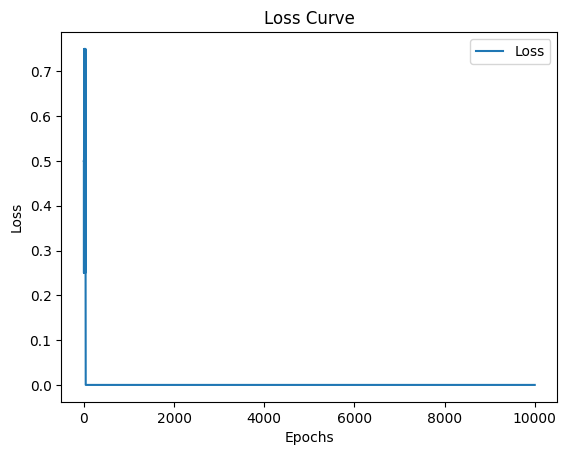

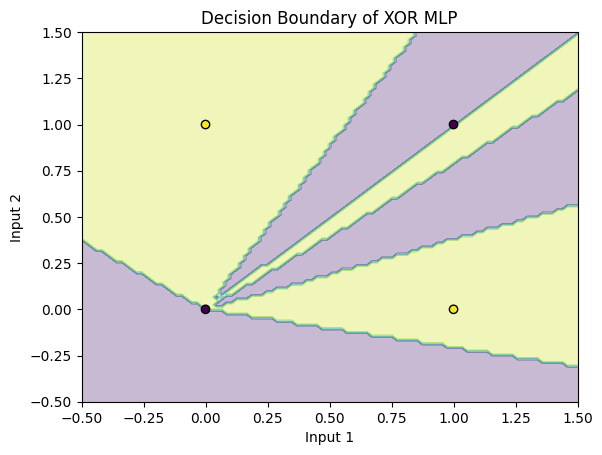

done :- 9


In [7]:
for i in range(10):
    test_mlp(hidden_size=i+1, learning_rate=0.01, epochs=10000)
    print(f"done :- {i}")